# Deteksi & Koreksi Typo Bahasa Indonesia (Traditional ML)

Sistem untuk mendeteksi dan mengoreksi typo pada teks Bahasa Indonesia memakai
machine learning klasik, tanpa deep learning. Model yang dibandingkan: Logistic
Regression, Complement Naive Bayes, Linear SVM, dan XGBoost.

Alur: inspeksi & pembersihan data, bangun kamus kata benar dan pasangan kata
salah→benar, latih model deteksi level kata dan level kalimat, lalu koreksi
dengan edit distance + kemiripan n-gram + frekuensi, dan terakhir menu interaktif.


## 1. Setup & Import Library

In [1]:
# Pasang pandas bila belum tersedia (library lain sudah ada di environment).
try:
    import pandas  # noqa: F401
except ImportError:
    %pip install -q pandas

import os
import re
import glob
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

from typo_lib import (tokenize, damerau_levenshtein, word_shape_features,
                      TypoCorrector, run_menu)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Semua library berhasil diimpor.")


Semua library berhasil diimpor.


## 2. Memuat Dataset

18 file CSV di folder `dataset/` (3 mata pelajaran x 6 jenis kesalahan). Tiap baris
berisi `kalimat_awal` (benar) dan `kalimat_salah` (mengandung satu typo).


In [2]:
csv_files = sorted(glob.glob(os.path.join("dataset", "*.csv")))
print(f"Jumlah file CSV ditemukan: {len(csv_files)}")

frames = [pd.read_csv(f, encoding="utf-8") for f in csv_files]
df = pd.concat(frames, ignore_index=True)

print(f"Total baris gabungan : {len(df):,}")
print(f"Kolom                : {list(df.columns)}")
df.head()


Jumlah file CSV ditemukan: 18


Total baris gabungan : 387,000
Kolom                : ['kalimat_awal', 'kalimat_salah', 'Pelajaran', 'tipe_kesalahan']


,kalimat_awal,kalimat_salah,Pelajaran,tipe_kesalahan
0,Bunyi apa?,Buni apa?,Bahasa Indonesia,Deletion Error
1,Siap-siap belajar.,Sia-siap belajar.,Bahasa Indonesia,Deletion Error
2,Diskusikan gambar sampul di atas dengan menjaw...,Diskusikan gambar sampul di atas dengan menawa...,Bahasa Indonesia,Deletion Error
3,Apa yang kalian lihat pada gambar di atas?,Apa yang kalian lihat pada gambar d atas?,Bahasa Indonesia,Deletion Error
4,"Menurut kalian, apa isi ceritanya?","Menurut kalian, apa si ceritanya?",Bahasa Indonesia,Deletion Error


## 3. Inspeksi Dataset (EDA)

In [3]:
print("=== INFO DATAFRAME ===")
df.info()

print("\n=== JUMLAH NILAI KOSONG (missing) PER KOLOM ===")
print(df.isnull().sum())

print("\n=== JUMLAH BARIS DUPLIKAT ===")
print(int(df.duplicated().sum()))


=== INFO DATAFRAME ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387000 entries, 0 to 386999
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   kalimat_awal    387000 non-null  object
 1   kalimat_salah   387000 non-null  object
 2   Pelajaran       387000 non-null  object
 3   tipe_kesalahan  387000 non-null  object
dtypes: object(4)
memory usage: 11.8+ MB

=== JUMLAH NILAI KOSONG (missing) PER KOLOM ===
kalimat_awal      0
kalimat_salah     0
Pelajaran         0
tipe_kesalahan    0
dtype: int64

=== JUMLAH BARIS DUPLIKAT ===


0


In [4]:
print("=== Distribusi per Pelajaran ===")
print(df["Pelajaran"].value_counts())
print("\n=== Distribusi per tipe_kesalahan ===")
print(df["tipe_kesalahan"].value_counts())


=== Distribusi per Pelajaran ===
Pelajaran
Bahasa Indonesia    129000
IPA                 129000
IPS                 129000
Name: count, dtype: int64

=== Distribusi per tipe_kesalahan ===
tipe_kesalahan
Deletion Error         64500
Insertion Error        64500
Punctuation Error      64500
Real word Error        64500
Subtitution Error      64500
Transposition Error    64500
Name: count, dtype: int64


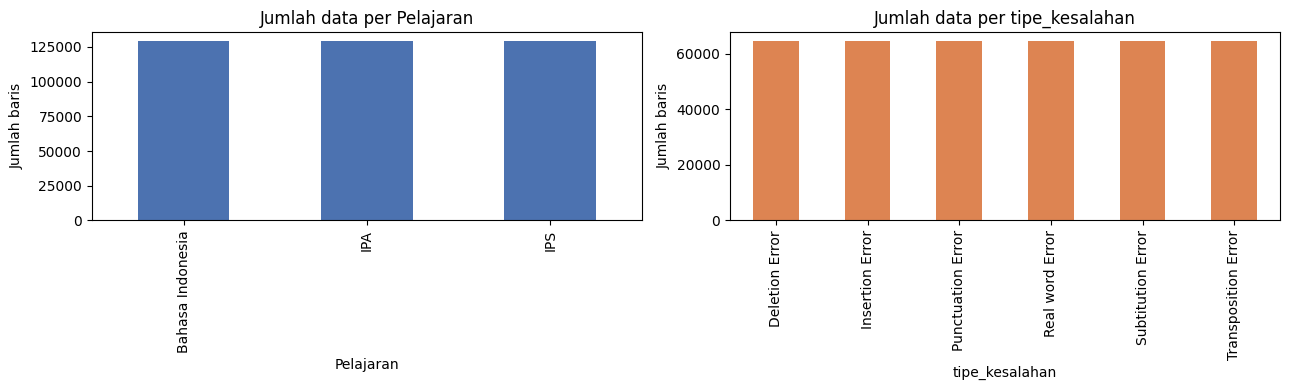

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["Pelajaran"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Jumlah data per Pelajaran")
axes[0].set_ylabel("Jumlah baris")
df["tipe_kesalahan"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Jumlah data per tipe_kesalahan")
axes[1].set_ylabel("Jumlah baris")
plt.tight_layout()
plt.show()


In [6]:
for tipe in df["tipe_kesalahan"].unique():
    contoh = df[df["tipe_kesalahan"] == tipe].iloc[0]
    print(f"[{tipe}]")
    print(f"   BENAR : {contoh['kalimat_awal']}")
    print(f"   SALAH : {contoh['kalimat_salah']}\n")


[Deletion Error]
   BENAR : Bunyi apa?
   SALAH : Buni apa?

[Insertion Error]
   BENAR : Bunyi apa?
   SALAH : Bunyti apa?

[Punctuation Error]
   BENAR : Bunyi apa?
   SALAH : Bunyi apa'

[Real word Error]
   BENAR : Bunyi apa?
   SALAH : Bunyi ala?

[Subtitution Error]
   BENAR : Bunyi apa?
   SALAH : Bunyx apa?

[Transposition Error]
   BENAR : Bunyi apa?
   SALAH : Ybuni apa?



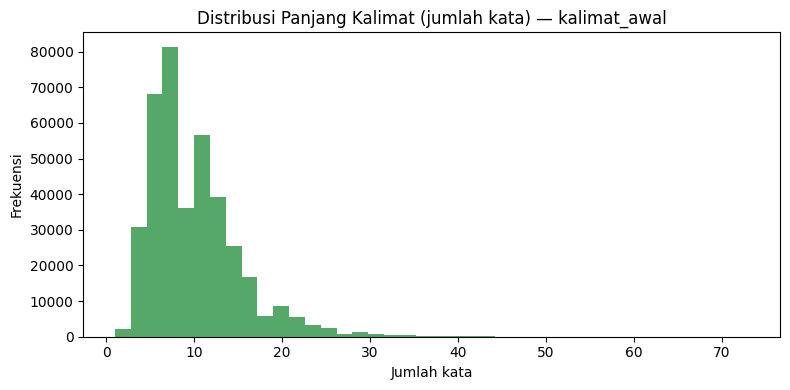

count    387000.000000
mean          9.900465
std           5.154054
min           1.000000
25%           6.000000
50%           9.000000
75%          12.000000
max          73.000000
Name: panjang_kata, dtype: float64


In [7]:
df["panjang_kata"] = df["kalimat_awal"].apply(lambda s: len(tokenize(s)))
plt.figure(figsize=(8, 4))
plt.hist(df["panjang_kata"], bins=40, color="#55A868")
plt.title("Distribusi Panjang Kalimat (jumlah kata) — kalimat_awal")
plt.xlabel("Jumlah kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()
print(df["panjang_kata"].describe())


## 4. Pembersihan Data

Rapikan spasi, buang baris kosong dan duplikat, serta buang pasangan yang
`kalimat_awal` sama persis dengan `kalimat_salah`.


In [8]:
baris_awal = len(df)

for col in ["kalimat_awal", "kalimat_salah"]:
    df[col] = df[col].astype(str).str.strip()

df = df.dropna(subset=["kalimat_awal", "kalimat_salah"])
df = df.drop_duplicates()
df = df[df["kalimat_awal"] != df["kalimat_salah"]].reset_index(drop=True)

print(f"Baris sebelum : {baris_awal:,}")
print(f"Baris sesudah : {len(df):,}")
print(f"Baris dibuang : {baris_awal - len(df):,}")


Baris sebelum : 387,000
Baris sesudah : 382,206
Baris dibuang : 4,794


## 5. Kamus Kata Benar

Semua kata pada `kalimat_awal` adalah kata benar. Kita kumpulkan jadi
`Counter(kata -> frekuensi)`, lalu dipakai sebagai kelas "benar" untuk model
deteksi kata sekaligus sumber kandidat koreksi.


In [9]:
kalimat_benar_unik = df["kalimat_awal"].unique()
freq_kata = Counter()
for kal in kalimat_benar_unik:
    freq_kata.update(tokenize(kal))

vocab = sorted(freq_kata.keys())
print(f"Jumlah kalimat benar unik : {len(kalimat_benar_unik):,}")
print(f"Ukuran kosakata (vocab)   : {len(vocab):,}")
print("Contoh 15 kata paling sering:", freq_kata.most_common(15))


Jumlah kalimat benar unik : 64,434
Ukuran kosakata (vocab)   : 25,727
Contoh 15 kata paling sering: [('yang', 21237), ('dan', 16534), ('di', 12789), ('dengan', 8053), ('untuk', 5436), ('pada', 5416), ('dalam', 5299), ('ini', 5237), ('dapat', 5184), ('dari', 5127), ('itu', 4419), ('atau', 3878), ('kamu', 3840), ('adalah', 3809), ('tersebut', 3670)]


## 6. Ekstraksi Pasangan Kata (salah -> benar)

Selaraskan token tiap pasangan kalimat dengan `difflib.SequenceMatcher`. Bagian
yang berubah memberi pasangan (kata_benar, kata_salah) yang dipakai untuk melatih
deteksi kata dan mengevaluasi koreksi.


In [10]:
from difflib import SequenceMatcher

def ekstrak_pasangan_kata(kalimat_benar, kalimat_salah):
    a = tokenize(kalimat_benar)
    b = tokenize(kalimat_salah)
    pasangan = []
    sm = SequenceMatcher(a=a, b=b, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "replace":
            for k in range(max(i2 - i1, j2 - j1)):
                wb = a[i1 + k] if i1 + k < i2 else ""
                ws = b[j1 + k] if j1 + k < j2 else ""
                if wb and ws and wb != ws:
                    pasangan.append((wb, ws))
        elif tag == "delete":
            for k in range(i1, i2):
                pasangan.append((a[k], ""))
        elif tag == "insert":
            for k in range(j1, j2):
                pasangan.append(("", b[k]))
    return pasangan

records = []
for benar, salah, tipe in zip(df["kalimat_awal"], df["kalimat_salah"], df["tipe_kesalahan"]):
    for wb, ws in ekstrak_pasangan_kata(benar, salah):
        records.append((wb, ws, tipe))

pairs = pd.DataFrame(records, columns=["kata_benar", "kata_salah", "tipe_kesalahan"])
print(f"Total pasangan kata terekstrak: {len(pairs):,}")
pairs.head(10)


Total pasangan kata terekstrak: 329,723


,kata_benar,kata_salah,tipe_kesalahan
0,bunyi,buni,Deletion Error
1,siap-siap,sia-siap,Deletion Error
2,menjawab,menawab,Deletion Error
3,di,d,Deletion Error
4,isi,si,Deletion Error
5,cerita,ceria,Deletion Error
6,boni,bon,Deletion Error
7,biru,bir,Deletion Error
8,jadi,jad,Deletion Error
9,boni,bon,Deletion Error


## 7. Data Deteksi Level-Kata

Label 1 = kata typo dari error ortografis (Deletion, Insertion, Subtitution,
Transposition, Punctuation); label 0 = kata dari kosakata benar. Real word error
dikecualikan karena typonya kata valid (ditangani model kalimat). Kelas
diseimbangkan lalu disubsample agar pelatihan cepat.


In [11]:
ERROR_ORTOGRAFIS = ["Deletion Error", "Insertion Error", "Subtitution Error",
                    "Transposition Error", "Punctuation Error"]

typo_words = pairs[(pairs["tipe_kesalahan"].isin(ERROR_ORTOGRAFIS)) &
                   (pairs["kata_salah"].str.len() > 0)]["kata_salah"]
vocab_set = set(vocab)
typo_words = [w for w in typo_words if w not in vocab_set]

MAX_PER_KELAS = 40000
rng = np.random.default_rng(RANDOM_STATE)

typo_unique = np.array(sorted(set(typo_words)))
if len(typo_unique) > MAX_PER_KELAS:
    typo_sample = rng.choice(typo_unique, MAX_PER_KELAS, replace=False)
else:
    typo_sample = typo_unique

vocab_arr = np.array(vocab)
n_neg = min(len(vocab_arr), len(typo_sample))
benar_sample = rng.choice(vocab_arr, n_neg, replace=False)

X_word = np.concatenate([typo_sample, benar_sample])
y_word = np.concatenate([np.ones(len(typo_sample), dtype=int),
                         np.zeros(len(benar_sample), dtype=int)])

print(f"Jumlah contoh typo (label 1) : {len(typo_sample):,}")
print(f"Jumlah contoh benar (label 0): {len(benar_sample):,}")
print(f"Total data deteksi kata      : {len(X_word):,}")


Jumlah contoh typo (label 1) : 40,000
Jumlah contoh benar (label 0): 25,727
Total data deteksi kata      : 65,727


## 8-9. Fitur & Pelatihan Model Deteksi Level-Kata

Fitur utama: TF-IDF n-gram karakter (`char_wb`, ngram 2-4), efektif menangkap
pola ejaan tak lazim akibat typo. Fitur bentuk-kata lain (panjang, rasio vokal,
edit distance, pola keyboard) dipakai pada tahap koreksi. Latih dan bandingkan 4
model: Logistic Regression, Complement NB, Linear SVM (dikalibrasi), XGBoost.


In [12]:
print("Contoh fitur bentuk-kata:")
for w in ["belajar", "bljar", "bunyti", "ybuni"]:
    print(f"  {w:10s} -> {word_shape_features(w)}")


Contoh fitur bentuk-kata:
  belajar    -> {'panjang': 7, 'rasio_vokal': 0.42857142857142855, 'deret_konsonan_max': 1, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  bljar      -> {'panjang': 5, 'rasio_vokal': 0.2, 'deret_konsonan_max': 3, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  bunyti     -> {'panjang': 6, 'rasio_vokal': 0.3333333333333333, 'deret_konsonan_max': 3, 'ada_angka': 0, 'ada_huruf_berulang': 0}
  ybuni      -> {'panjang': 5, 'rasio_vokal': 0.4, 'deret_konsonan_max': 2, 'ada_angka': 0, 'ada_huruf_berulang': 0}


In [13]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_word, y_word, test_size=0.2, random_state=RANDOM_STATE, stratify=y_word)

def buat_pipeline_kata(clf):
    return Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4),
                                  min_df=2, max_features=50000)),
        ("clf", clf),
    ])

model_kata = {
    "Logistic Regression": buat_pipeline_kata(
        LogisticRegression(max_iter=1000, C=5.0)),
    "Complement NB": buat_pipeline_kata(ComplementNB()),
    "Linear SVM": buat_pipeline_kata(
        CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)),
    "XGBoost": buat_pipeline_kata(
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                      tree_method="hist", n_jobs=-1, eval_metric="logloss",
                      random_state=RANDOM_STATE)),
}

hasil_kata = {}
for nama, pipe in model_kata.items():
    print(f"Melatih: {nama} ...")
    pipe.fit(Xw_train, yw_train)
    pred = pipe.predict(Xw_test)
    proba = pipe.predict_proba(Xw_test)[:, 1]
    hasil_kata[nama] = {
        "accuracy": accuracy_score(yw_test, pred),
        "precision": precision_score(yw_test, pred),
        "recall": recall_score(yw_test, pred),
        "f1": f1_score(yw_test, pred),
        "roc_auc": roc_auc_score(yw_test, proba),
    }
print("Selesai melatih semua model kata.")


Melatih: Logistic Regression ...


Melatih: Complement NB ...


Melatih: Linear SVM ...


Melatih: XGBoost ...


Selesai melatih semua model kata.


## 10. Evaluasi & Pemilihan Model Deteksi Level-Kata

In [14]:
tabel_kata = pd.DataFrame(hasil_kata).T.sort_values("f1", ascending=False)
print("=== Perbandingan Model Deteksi KATA ===")
display(tabel_kata.style.format("{:.4f}"))

best_word_name = tabel_kata.index[0]
best_word_model = model_kata[best_word_name]
print(f"\nModel KATA terbaik: {best_word_name} (F1={tabel_kata.loc[best_word_name,'f1']:.4f})")


=== Perbandingan Model Deteksi KATA ===


,accuracy,precision,recall,f1,roc_auc
Linear SVM,0.8293,0.8641,0.8538,0.8589,0.8994
Logistic Regression,0.8269,0.8658,0.8468,0.8562,0.8979
XGBoost,0.7797,0.8187,0.8195,0.8191,0.8649
Complement NB,0.7811,0.8752,0.7468,0.8059,0.8664



Model KATA terbaik: Linear SVM (F1=0.8589)


=== Classification Report — Linear SVM (deteksi KATA) ===
              precision    recall  f1-score   support

       benar       0.78      0.79      0.78      5146
        typo       0.86      0.85      0.86      8000

    accuracy                           0.83     13146
   macro avg       0.82      0.82      0.82     13146
weighted avg       0.83      0.83      0.83     13146



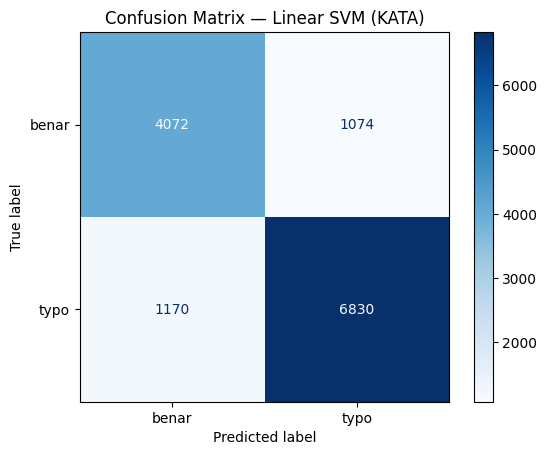

In [15]:
pred_best = best_word_model.predict(Xw_test)
print(f"=== Classification Report — {best_word_name} (deteksi KATA) ===")
print(classification_report(yw_test, pred_best, target_names=["benar", "typo"]))

cm = confusion_matrix(yw_test, pred_best)
ConfusionMatrixDisplay(cm, display_labels=["benar", "typo"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_word_name} (KATA)")
plt.show()


## 11. Data Deteksi Level-Kalimat

Label 0 = `kalimat_awal` (benar), label 1 = `kalimat_salah` (typo). Model kalimat
memakai konteks n-gram kata sehingga bisa menangkap real word error. Subsample
berstratifikasi per pelajaran dan tipe kesalahan.


In [16]:
N_PER_TIPE = 2500   # per (pelajaran x tipe_kesalahan)
contoh = (df.groupby(["Pelajaran", "tipe_kesalahan"], group_keys=False)
            .apply(lambda g: g.sample(min(len(g), N_PER_TIPE), random_state=RANDOM_STATE)))

benar_df = pd.DataFrame({"teks": contoh["kalimat_awal"], "label": 0,
                         "tipe": "Benar"})
salah_df = pd.DataFrame({"teks": contoh["kalimat_salah"], "label": 1,
                         "tipe": contoh["tipe_kesalahan"]})
data_kalimat = pd.concat([benar_df, salah_df], ignore_index=True)
data_kalimat = data_kalimat.drop_duplicates(subset=["teks", "label"]).reset_index(drop=True)

print(f"Total data kalimat: {len(data_kalimat):,}")
print(data_kalimat["label"].value_counts())


Total data kalimat: 59,108
label
1    44997
0    14111
Name: count, dtype: int64


## 12-13. Fitur & Pelatihan Model Deteksi Level-Kalimat

Fitur gabungan (`FeatureUnion`): TF-IDF n-gram kata (1,2) dan n-gram karakter
(2,4). Latih dan bandingkan 4 model klasik yang sama.


In [17]:
Xs = data_kalimat["teks"].values
ys = data_kalimat["label"].values
tipe_s = data_kalimat["tipe"].values

Xs_train, Xs_test, ys_train, ys_test, tipe_train, tipe_test = train_test_split(
    Xs, ys, tipe_s, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)

def buat_pipeline_kalimat(clf):
    fitur = FeatureUnion([
        ("kata", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                 min_df=2, max_features=50000)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4),
                                 min_df=2, max_features=50000)),
    ])
    return Pipeline([("fitur", fitur), ("clf", clf)])

model_kalimat = {
    "Logistic Regression": buat_pipeline_kalimat(
        LogisticRegression(max_iter=1000, C=5.0)),
    "Complement NB": buat_pipeline_kalimat(ComplementNB()),
    "Linear SVM": buat_pipeline_kalimat(
        CalibratedClassifierCV(LinearSVC(C=1.0), cv=3)),
    "XGBoost": buat_pipeline_kalimat(
        XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.3,
                      tree_method="hist", n_jobs=-1, eval_metric="logloss",
                      random_state=RANDOM_STATE)),
}

hasil_kalimat = {}
for nama, pipe in model_kalimat.items():
    print(f"Melatih: {nama} ...")
    pipe.fit(Xs_train, ys_train)
    pred = pipe.predict(Xs_test)
    proba = pipe.predict_proba(Xs_test)[:, 1]
    hasil_kalimat[nama] = {
        "accuracy": accuracy_score(ys_test, pred),
        "precision": precision_score(ys_test, pred),
        "recall": recall_score(ys_test, pred),
        "f1": f1_score(ys_test, pred),
        "roc_auc": roc_auc_score(ys_test, proba),
    }
print("Selesai melatih semua model kalimat.")


Melatih: Logistic Regression ...


Melatih: Complement NB ...


Melatih: Linear SVM ...


Melatih: XGBoost ...


Selesai melatih semua model kalimat.


=== Perbandingan Model Deteksi KALIMAT ===


,accuracy,precision,recall,f1,roc_auc
Linear SVM,0.8334,0.8489,0.9503,0.8968,0.8680
Logistic Regression,0.8099,0.8275,0.9479,0.8836,0.8356
XGBoost,0.7673,0.7850,0.9563,0.8622,0.8232
Complement NB,0.7265,0.7544,0.9500,0.8410,0.4843



Model KALIMAT terbaik: Linear SVM (F1=0.8968)


              precision    recall  f1-score   support

       benar       0.74      0.46      0.57      2822
        typo       0.85      0.95      0.90      9000

    accuracy                           0.83     11822
   macro avg       0.80      0.71      0.73     11822
weighted avg       0.82      0.83      0.82     11822



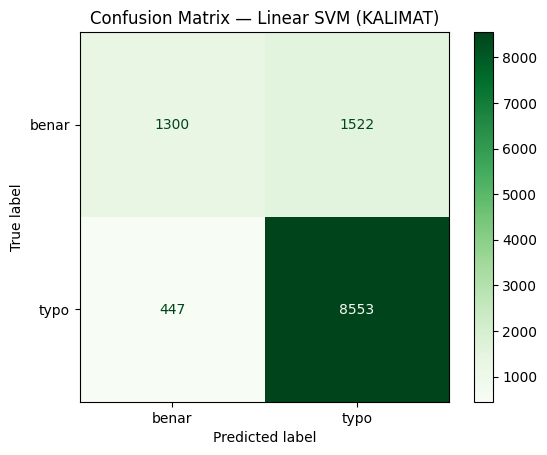

In [18]:
tabel_kalimat = pd.DataFrame(hasil_kalimat).T.sort_values("f1", ascending=False)
print("=== Perbandingan Model Deteksi KALIMAT ===")
display(tabel_kalimat.style.format("{:.4f}"))

best_sent_name = tabel_kalimat.index[0]
best_sent_model = model_kalimat[best_sent_name]
print(f"\nModel KALIMAT terbaik: {best_sent_name} (F1={tabel_kalimat.loc[best_sent_name,'f1']:.4f})")

pred_s = best_sent_model.predict(Xs_test)
print(classification_report(ys_test, pred_s, target_names=["benar", "typo"]))
cm_s = confusion_matrix(ys_test, pred_s)
ConfusionMatrixDisplay(cm_s, display_labels=["benar", "typo"]).plot(cmap="Greens")
plt.title(f"Confusion Matrix — {best_sent_name} (KALIMAT)")
plt.show()


In [19]:
# Recall per jenis kesalahan: terlihat seberapa baik real word error tertangkap.
mask_typo = ys_test == 1
df_eval = pd.DataFrame({"tipe": tipe_test[mask_typo],
                        "benar_terdeteksi": pred_s[mask_typo] == 1})
recall_per_tipe = df_eval.groupby("tipe")["benar_terdeteksi"].mean().sort_values()
print("=== Recall per tipe kesalahan (model KALIMAT) ===")
print((recall_per_tipe * 100).round(2).astype(str) + " %")


=== Recall per tipe kesalahan (model KALIMAT) ===
tipe
Real word Error        83.64 %
Deletion Error         94.03 %
Transposition Error    97.34 %
Subtitution Error      98.02 %
Insertion Error        98.72 %
Punctuation Error      98.86 %
Name: benar_terdeteksi, dtype: object


## 14. Modul Koreksi (Non-Deep-Learning)

Kandidat koreksi diambil dari kosakata benar lalu diperingkat dengan kombinasi:
cosine TF-IDF n-gram karakter, edit distance Damerau-Levenshtein, frekuensi kata,
dan bonus pola keyboard. Kita bangun indeks kemiripan lalu rakit `TypoCorrector`.


In [20]:
index_vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
index_matrix = index_vectorizer.fit_transform(vocab)   # L2-normalized
print(f"Indeks kemiripan dibangun: {index_matrix.shape[0]:,} kata, "
      f"{index_matrix.shape[1]:,} fitur n-gram.")

corrector = TypoCorrector(
    word_model=best_word_model,
    sentence_model=best_sent_model,
    correction_freq=dict(freq_kata),
    index_vectorizer=index_vectorizer,
    index_matrix=index_matrix,
    vocab=vocab,
)
print("TypoCorrector siap digunakan.")


Indeks kemiripan dibangun: 25,727 kata, 35,686 fitur n-gram.
TypoCorrector siap digunakan.


In [21]:
for contoh in ["Buni apa?", "Bunyi apa?", "bljar", "Siswa sedang menulis surat."]:
    d = corrector.detect_typo(contoh)
    s = corrector.suggest_correction(contoh)
    print(f"INPUT   : {contoh}")
    print(f"  deteksi : is_typo={d['is_typo']} | confidence={d['confidence']:.2%}")
    print(f"  koreksi : {s['corrected']}")
    if s["is_typo"]:
        print(f"  saran   : {s['suggestions']}")
    print()


INPUT   : Buni apa?
  deteksi : is_typo=True | confidence=92.91%
  koreksi : Bunyi apa?
  saran   : {'buni': [('bunyi', 0.5788225790683963), ('bung', 0.5584628124421328), ('juni', 0.51415401748949)]}

INPUT   : Bunyi apa?
  deteksi : is_typo=False | confidence=91.05%
  koreksi : Bunyi apa?

INPUT   : bljar
  deteksi : is_typo=True | confidence=89.03%
  koreksi : belajar
  saran   : {'bljar': [('belajar', 0.5388639951234541), ('banjar', 0.4396444305819648), ('blitar', 0.43146248698780426)]}

INPUT   : Siswa sedang menulis surat.
  deteksi : is_typo=False | confidence=78.98%
  koreksi : Siswa sedang menulis surat.



## 15. Evaluasi Koreksi (Top-1 & Top-3)

Uji koreksi pada pasangan (kata_salah -> kata_benar) yang ditahan. Top-1 = kandidat
peringkat 1 benar; Top-3 = kata benar ada di 3 teratas. Real word error
diperkirakan rendah karena typonya berupa kata valid.


In [22]:
eval_pairs = pairs[(pairs["kata_salah"].str.len() > 0) &
                   (pairs["kata_benar"].str.len() > 0)].copy()
eval_pairs = eval_pairs[eval_pairs["kata_salah"] != eval_pairs["kata_benar"]]
eval_sample = eval_pairs.sample(min(4000, len(eval_pairs)), random_state=RANDOM_STATE)

def eval_koreksi(row, k=3):
    cands = [c for c, _ in corrector.candidates(row["kata_salah"], k=k)]
    top1 = bool(cands and cands[0] == row["kata_benar"])
    topk = bool(row["kata_benar"] in cands)
    return pd.Series({"top1": top1, "top3": topk})

hasil_koreksi = eval_sample.join(eval_sample.apply(eval_koreksi, axis=1))
print("=== Akurasi Koreksi (SEMUA pasangan, termasuk real-word) ===")
print(f"Top-1 : {hasil_koreksi['top1'].mean():.2%}")
print(f"Top-3 : {hasil_koreksi['top3'].mean():.2%}")

# Skenario realistis: typo yang benar-benar di luar kamus (OOV) dengan target dikenal.
vset = set(vocab)
oov_mask = (~hasil_koreksi["kata_salah"].isin(vset)) & (hasil_koreksi["kata_benar"].isin(vset))
oov_res = hasil_koreksi[oov_mask]
print(f"\n=== Akurasi Koreksi (khusus typo di luar kamus/OOV, n={len(oov_res):,}) ===")
print(f"Top-1 : {oov_res['top1'].mean():.2%}")
print(f"Top-3 : {oov_res['top3'].mean():.2%}")

print("\n=== Akurasi Koreksi per tipe kesalahan ===")
display((hasil_koreksi.groupby("tipe_kesalahan")[["top1", "top3"]]
         .mean().mul(100).round(2)).style.format("{:.2f}%"))


=== Akurasi Koreksi (SEMUA pasangan, termasuk real-word) ===
Top-1 : 59.08%
Top-3 : 82.55%

=== Akurasi Koreksi (khusus typo di luar kamus/OOV, n=2,922) ===
Top-1 : 79.91%
Top-3 : 90.18%

=== Akurasi Koreksi per tipe kesalahan ===


,top1,top3
tipe_kesalahan,,
Deletion Error,64.47%,89.38%
Insertion Error,94.90%,99.48%
Punctuation Error,1.27%,25.32%
Real word Error,8.93%,71.09%
Subtitution Error,80.53%,87.28%
Transposition Error,55.15%,71.78%


## 16. Menyimpan Artefak

Simpan model, vectorizer, dan kamus ke folder `models/` dengan joblib agar bisa
dimuat ulang oleh `typo_app.py` dan `streamlit_app.py` tanpa pelatihan ulang.


In [23]:
corrector.config["best_word_model"] = best_word_name
corrector.config["best_sentence_model"] = best_sent_name
corrector.config["metrik_kata"] = hasil_kata[best_word_name]
corrector.config["metrik_kalimat"] = hasil_kalimat[best_sent_name]

corrector.save("models")
print("Artefak tersimpan di folder 'models/':")
for f in sorted(os.listdir("models")):
    ukuran = os.path.getsize(os.path.join("models", f)) / 1024
    print(f"  - {f:28s} ({ukuran:,.1f} KB)")


Artefak tersimpan di folder 'models/':
  - correction_dict.joblib       (452.2 KB)
  - correction_index.joblib      (8,002.3 KB)
  - metadata.joblib              (0.5 KB)
  - sentence_model.joblib        (5,618.5 KB)
  - word_model.joblib            (2,235.9 KB)


## 17. Menu Interaktif

Jalankan sel berikut untuk uji interaktif di dalam notebook, atau dari terminal:
`python typo_app.py`. Saat eksekusi non-interaktif menu berhenti dengan rapi.


In [24]:
corrector_loaded = TypoCorrector.load("models")
run_menu(corrector_loaded)


  SISTEM DETEKSI & KOREKSI TYPO (Traditional ML)

MENU:
  1. Periksa kata / kalimat (deteksi + koreksi)
  2. Keluar

[Info] Input interaktif tidak tersedia. Menu dihentikan.
